# nb26 — Feasibility gates for a multi-band astrometry head

nb25 (the Fisher field guide) established that the position head exactly saturates the
VIS pixel Cramér–Rao bound (7.7 ≈ 8.0 mas at peak SNR 10) while a classical joint 10-band
fit reaches the all-band bound (3.42 ≈ 3.40 mas) on injections, with independent per-band
errors and a verified information-addition law. The head's gap is therefore architectural
(it reads only the fused bottleneck + VIS stem). Before designing a head that closes it,
two gates:

**Gate 0 — realistic-SED headroom.** The idealized ×5.5 assumed equal peak SNR in all ten
bands. Measure per-band peak amplitudes for real detected sources on held-out tiles and
re-ask the CRB with real SEDs: how much multi-band gain actually exists, and in which
bands?

**Gate 1 — stem sufficiency, by the decoder bound.** A head can only read what its inputs
contain. Per band, train a linear ridge reader from the stem window to the injected
offset and score it on held-out truth — an actual estimator's scatter is a valid,
assumption-free information lower bound. (Why not a Monte-Carlo Fisher estimate of the
stems? It fabricates information at any realistic realization budget — the zero-signal
null test in nb25 §3 demonstrates the failure; the decoder is the honest instrument,
nb25 §4.)

Real-sky context for both gates: collectible gains are further capped by inter-band error
correlations (the paper's concordance field; nb27), which floor the bright end and leave
the faint end as the head's honest target.

In [1]:
import sys, json, time
from pathlib import Path

def find_repo_root(s=None):
    s = (s or Path.cwd()).resolve()
    for c in [s, *s.parents]:
        if (c/'models').exists() and (c/'data').exists():
            return c
    raise FileNotFoundError('repo root')

REPO = find_repo_root()
for p in (REPO/'models', REPO, REPO/'models'/'astrometry2'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from scipy.spatial import cKDTree

from astrometry2.latent_position_head import load_latent_position_head, extract_local_windows
from astrometry2.source_matching import safe_header_from_card_string
from astrometry2.dataset import build_full_context_detector_inputs, refine_centroids_psf_fit

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
OUT = REPO/'io'/'_nb26_outputs'
OUT.mkdir(exist_ok=True)

FOUNDATION = REPO/'models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt'
CFG = dict(
    # step 0
    n_tiles_sed = 12,     # held-out patch-25 tiles for the SED census
    min_sep_px  = 15.0,   # source separation cut (reduce blends)
    vis_snr_min = 3.0,    # keep sources detected at least this strongly in VIS
    # step 1 (mirrors nb25)
    tile_index = 0, n_src = 16, snr = 10.0, delta_px = 0.25,
    n_center = 128, n_jac = 8, seed = 20260811,
)
SIGMA_PX = {'VIS': 2.5/2.355, 'NISP': 2.5/2.355, 'RUBIN': 3.0/2.355}
RUBIN_BANDS = ['u','g','r','i','z','y']
NISP_BANDS  = ['Y','J','H']
VIS_MAS, RUBIN_MAS = 100.0, 200.0

LAB = torch.load(REPO/'data/detection_labels/centernet_q1_790_vissep_thresh03.pt',
                 map_location='cpu', weights_only=False)
LAB = LAB['labels'] if 'labels' in LAB else LAB
rdir, edir = REPO/'data/rubin_tiles_patch25', REPO/'data/euclid_tiles_all_q1'
STEMS25 = sorted(p.name[:-4] for p in rdir.glob('tile_*.npz'))
print(DEVICE, len(STEMS25), 'patch-25 tiles')

cuda:0 108 patch-25 tiles


In [2]:
# ---- shared helpers (nb25 conventions) ----
def local_rms(rms_img, x, y):
    xi = int(np.clip(round(float(x)), 0, rms_img.shape[1]-1))
    yi = int(np.clip(round(float(y)), 0, rms_img.shape[0]-1))
    v = float(rms_img[yi, xi])
    return v if np.isfinite(v) and v > 0 else float(np.nanmedian(rms_img))

def pixel_fisher_band(amp, x, y, sigma, var_local):
    # per-axis Fisher (band px^-2) of an isotropic Gaussian, peak amp, pixel-centre sampling
    r = int(max(8, np.ceil(5*sigma)))
    yy, xx = np.mgrid[-r:r+1, -r:r+1].astype(np.float64)
    xx += (x - round(x)); yy += (y - round(y))
    g = np.exp(-0.5*(xx**2 + yy**2)/sigma**2)
    return float(((amp*(xx/sigma**2)*g)**2).sum() / var_local)

def inject_gauss(img, x, y, sigma, amp):
    Hh, Ww = img.shape
    r = int(max(6, np.ceil(4*sigma)))
    x0, x1 = max(0, int(x)-r), min(Ww, int(x)+r+1)
    y0, y1 = max(0, int(y)-r), min(Hh, int(y)+r+1)
    yy, xx = np.mgrid[y0:y1, x0:x1]
    img[y0:y1, x0:x1] += (amp*np.exp(-0.5*(((xx-x)/sigma)**2 + ((yy-y)/sigma)**2))).astype(img.dtype)

def fit_amp(img, rms_img, cx, cy, sigma, R):
    # weighted LSQ amplitude (+ constant background) of a fixed-position Gaussian
    Hh, Ww = img.shape
    x0, y0 = int(round(cx))-R, int(round(cy))-R
    if x0 < 0 or y0 < 0 or x0+2*R+1 > Ww or y0+2*R+1 > Hh:
        return np.nan, np.nan
    st = img[y0:y0+2*R+1, x0:x0+2*R+1].astype(np.float64)
    sr = rms_img[y0:y0+2*R+1, x0:x0+2*R+1].astype(np.float64)
    if not np.isfinite(st).all():
        return np.nan, np.nan
    yy, xx = np.mgrid[y0:y0+2*R+1, x0:x0+2*R+1]
    g = np.exp(-0.5*(((xx-cx)/sigma)**2 + ((yy-cy)/sigma)**2))
    w = 1.0/np.clip(sr, 1e-12, None)**2
    M = np.stack([g.ravel(), np.ones(g.size)], axis=1)
    Wv = w.ravel()
    try:
        coef = np.linalg.solve(M.T @ (M*Wv[:, None]), M.T @ (Wv*st.ravel()))
    except np.linalg.LinAlgError:
        return np.nan, np.nan
    return float(coef[0]), local_rms(rms_img, cx, cy)

def band_info_for(edata, rdata):
    vwcs = WCS(safe_header_from_card_string(edata['wcs_VIS'].item()))
    rwcs = WCS(rdata['wcs_hdr'].item())
    info = {}
    for b in ['VIS'] + NISP_BANDS:
        w = vwcs if b == 'VIS' else WCS(safe_header_from_card_string(edata[f'wcs_{b}'].item()))
        info[f'euclid_{b}'] = (w, VIS_MAS, SIGMA_PX['VIS' if b == 'VIS' else 'NISP'])
    for b in RUBIN_BANDS:
        info[f'rubin_{b}'] = (rwcs, RUBIN_MAS, SIGMA_PX['RUBIN'])
    return info, vwcs

## Step 0 — realistic-SED headroom census

For each real detected source: refine the VIS position, project it into every band through
that band's WCS, fit the peak amplitude there, and convert to per-band pixel Fisher. The
per-source headroom is $\sigma_{\rm VIS}/\sigma_{\rm all} = \sqrt{F_{\rm all}/F_{\rm VIS}}$
— the factor by which a perfect multi-band estimator would shrink the error for *that
source's actual SED*. Negative fitted amplitudes contribute zero information.

In [3]:
ALL_BANDS_ORDER = None
rows_snr, rows_F, rows_vismag_proxy, rows_tile = [], [], [], []
t0 = time.time()
for stem in STEMS25[:CFG['n_tiles_sed']]:
    rdata = dict(np.load(rdir/f'{stem}.npz', allow_pickle=True))
    edata = dict(np.load(edir/f'{stem}_euclid.npz', allow_pickle=True))
    binfo, vwcs = band_info_for(edata, rdata)
    if ALL_BANDS_ORDER is None:
        ALL_BANDS_ORDER = list(binfo)
    imgs, rms, vis_hw = build_full_context_detector_inputs(edata, rdata['img'],
                                                           rubin_var=rdata.get('var'))
    Hh, Ww = vis_hw
    if stem not in LAB:
        continue
    ent = LAB[stem]
    xy_norm = np.asarray(ent[0] if isinstance(ent, tuple) else ent, dtype=np.float32)
    seeds = np.stack([xy_norm[:, 0]*(Ww-1), xy_norm[:, 1]*(Hh-1)], axis=1)
    # separation cut against blends, and stay off the edges
    tree = cKDTree(seeds)
    d2, _ = tree.query(seeds, k=2)
    keep = (d2[:, 1] > CFG['min_sep_px']) & (seeds[:, 0] > 60) & (seeds[:, 0] < Ww-60) \
           & (seeds[:, 1] > 60) & (seeds[:, 1] < Hh-60)
    seeds = seeds[keep]
    vis_xy, vis_snr, _ = refine_centroids_psf_fit(imgs['euclid_VIS'], seeds,
                                                  radius=3, fwhm_guess=2.5)
    ok = np.isfinite(vis_xy).all(1) & (vis_snr > CFG['vis_snr_min'])
    vis_xy = vis_xy[ok]
    ra, dec = vwcs.pixel_to_world_values(vis_xy[:, 0], vis_xy[:, 1])
    for j in range(len(vis_xy)):
        snr_vec, F_vec = [], []
        for band in ALL_BANDS_ORDER:
            bw, scale_mas, sig = binfo[band]
            bx, by = (float(v) for v in bw.world_to_pixel_values(ra[j], dec[j]))
            R = 9 if band.startswith('euclid') else 6
            amp, lr = fit_amp(imgs[band], rms[band], bx, by, sig, R)
            if not np.isfinite(amp) or not np.isfinite(lr):
                snr_vec.append(np.nan); F_vec.append(0.0)
                continue
            s = max(amp, 0.0)/lr
            snr_vec.append(s)
            F_vec.append(pixel_fisher_band(max(amp, 0.0), bx, by, sig, lr*lr)/scale_mas**2)
        rows_snr.append(snr_vec); rows_F.append(F_vec); rows_tile.append(stem)
    print(f'  {stem}: +{ok.sum()} sources ({(time.time()-t0)/60:.1f} min)', flush=True)

SNRm = np.asarray(rows_snr)          # [n_source, 10] peak SNR per band
Fm = np.asarray(rows_F)              # [n_source, 10] per-axis Fisher (mas^-2)
vis_i = ALL_BANDS_ORDER.index('euclid_VIS')
print(f'{len(Fm)} sources from {CFG["n_tiles_sed"]} tiles in {(time.time()-t0)/60:.1f} min')

  tile_x00000_y00000_tract5063_patch_25: +134 sources (0.0 min)


  tile_x00000_y00256_tract5063_patch_25: +142 sources (0.0 min)


  tile_x00000_y00512_tract5063_patch_25: +155 sources (0.0 min)


  tile_x00000_y00768_tract5063_patch_25: +107 sources (0.1 min)


  tile_x00000_y01024_tract5063_patch_25: +109 sources (0.1 min)


...

  tile_x00000_y02048_tract5063_patch_25: +143 sources (0.1 min)


  tile_x00000_y02304_tract5063_patch_25: +166 sources (0.1 min)


  tile_x00000_y02560_tract5063_patch_25: +166 sources (0.2 min)


  tile_x00000_y02816_tract5063_patch_25: +130 sources (0.2 min)


1710 sources from 12 tiles in 0.2 min


headroom sigma_VIS/sigma_all: median 1.47, quartiles [1.29, 1.84], 90th pct 2.33
  VIS peak SNR    3-10    : N= 1107  headroom 1.38  sigma_VIS   14.02 -> sigma_all    9.92 mas
  VIS peak SNR   10-30    : N=  455  headroom 1.63  sigma_VIS    5.62 -> sigma_all    3.22 mas
  VIS peak SNR   30-100   : N=   99  headroom 2.21  sigma_VIS    1.81 -> sigma_all    0.76 mas
  VIS peak SNR  100-1000000000: N=   13  headroom 5.00  sigma_VIS    0.32 -> sigma_all    0.07 mas


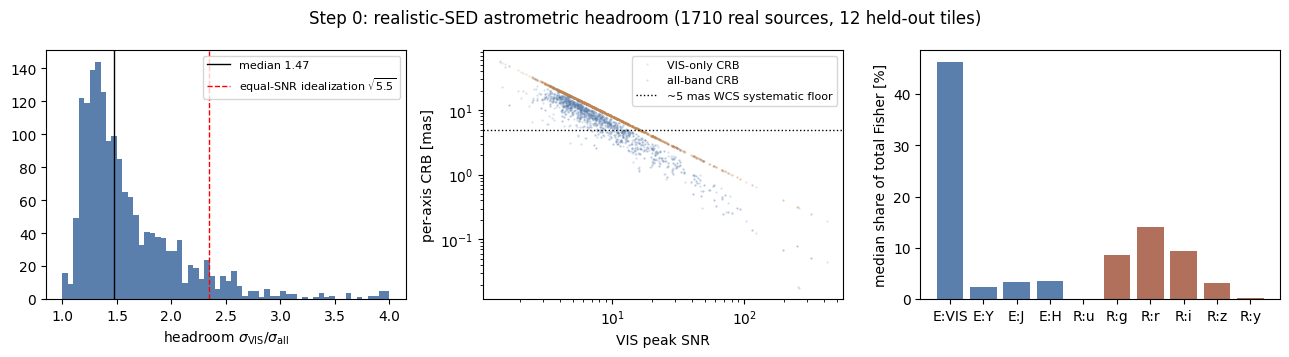

In [4]:
F_vis = Fm[:, vis_i]
F_all = Fm.sum(1)
good = F_vis > 0
headroom = np.sqrt(F_all[good]/F_vis[good])          # error-shrink factor per source
sig_vis = 1/np.sqrt(F_vis[good])
sig_all = 1/np.sqrt(F_all[good])
svis = SNRm[good, vis_i]

print(f'headroom sigma_VIS/sigma_all: median {np.median(headroom):.2f}, '
      f'quartiles [{np.percentile(headroom,25):.2f}, {np.percentile(headroom,75):.2f}], '
      f'90th pct {np.percentile(headroom,90):.2f}')
for lo, hi in [(3,10), (10,30), (30,100), (100,1e9)]:
    m = (svis >= lo) & (svis < hi)
    if m.sum() > 10:
        print(f'  VIS peak SNR {lo:>4.0f}-{hi:<6.0f}: N={m.sum():5d}  headroom {np.median(headroom[m]):.2f}  '
              f'sigma_VIS {np.median(sig_vis[m]):7.2f} -> sigma_all {np.median(sig_all[m]):7.2f} mas')

# which bands carry the information, for real SEDs
frac = np.median(Fm[good]/F_all[good, None], axis=0)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(headroom, bins=np.linspace(1, 4, 61), color='#5b7fad')
axes[0].axvline(np.median(headroom), c='k', lw=1,
                label=f'median {np.median(headroom):.2f}')
axes[0].axvline(np.sqrt(5.5), c='r', ls='--', lw=1, label=r'equal-SNR idealization $\sqrt{5.5}$')
axes[0].set_xlabel(r'headroom $\sigma_{\rm VIS}/\sigma_{\rm all}$'); axes[0].legend(fontsize=8)
o = np.argsort(svis)
axes[1].plot(svis[o], sig_vis[o], '.', ms=1, alpha=.25, color='#c08552', label='VIS-only CRB')
axes[1].plot(svis[o], sig_all[o], '.', ms=1, alpha=.25, color='#5b7fad', label='all-band CRB')
axes[1].axhline(5, c='k', ls=':', lw=1, label='~5 mas WCS systematic floor')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('VIS peak SNR'); axes[1].set_ylabel('per-axis CRB [mas]'); axes[1].legend(fontsize=8)
short = [b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in ALL_BANDS_ORDER]
axes[2].bar(range(len(short)), 100*frac,
            color=['#5b7fad' if b.startswith('euclid') else '#b0705c' for b in ALL_BANDS_ORDER])
axes[2].set_xticks(range(len(short))); axes[2].set_xticklabels(short)
axes[2].set_ylabel('median share of total Fisher [%]')
plt.suptitle(f'Step 0: realistic-SED astrometric headroom ({good.sum()} real sources, {CFG["n_tiles_sed"]} held-out tiles)')
plt.tight_layout(); plt.savefig(OUT/'step0_sed_headroom.png', dpi=150); plt.show()

np.savez(OUT/'step0_sed_census.npz', snr=SNRm, F=Fm,
         bands=np.array(ALL_BANDS_ORDER), tiles=np.array(rows_tile))

## Gate 1 setup — same tile, sites, and conventions as nb25

Peak SNR 10 injections at fixed sub-pixel truth (each band through its own WCS), fresh
noise from the variance maps. The pixel CRBs computed here are the per-band ceilings the
decoder readers are scored against.

In [5]:
stem0 = STEMS25[CFG['tile_index']]
rdata = dict(np.load(rdir/f'{stem0}.npz', allow_pickle=True))
edata = dict(np.load(edir/f'{stem0}_euclid.npz', allow_pickle=True))
BAND_INFO, vwcs = band_info_for(edata, rdata)
base_images, tile_rms, vis_hw = build_full_context_detector_inputs(edata, rdata['img'],
                                                                   rubin_var=rdata.get('var'))
H, W = vis_hw
rng = np.random.default_rng(CFG['seed'])
ent = LAB[stem0]
xy_norm = np.asarray(ent[0] if isinstance(ent, tuple) else ent, dtype=np.float32)
tree = cKDTree(np.stack([xy_norm[:, 0]*(W-1), xy_norm[:, 1]*(H-1)], axis=1))
pts = []
while len(pts) < CFG['n_src']:
    x, y = rng.uniform(120, W-120), rng.uniform(120, H-120)
    if np.isfinite(tree.query([[x, y]], distance_upper_bound=25.0)[0][0]):
        continue
    if pts and np.min(np.hypot(*(np.asarray(pts) - [x, y]).T)) < 80:
        continue
    pts.append([x, y])
pts = np.asarray(pts, np.float32)
ra0, dec0 = vwcs.pixel_to_world_values(pts[:, 0], pts[:, 1])

fe, _ = load_latent_position_head(str(FOUNDATION), device=DEVICE,
                                  bottleneck_window=5, stem_window=17)
BPX0 = {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    bx, by = bw.world_to_pixel_values(ra0, dec0)
    BPX0[band] = np.stack([bx, by], axis=1).astype(np.float32)
print('sites ready on', stem0)

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_q1_long/checkpoint_best.pt
  bottleneck_window=5  (physical coverage: 2.0" at 0.40"/px)
LatentPositionHead: 0.69M trainable, 7.3M frozen encoder  (v10 foundation)
sites ready on tile_x00000_y00000_tract5063_patch_25


In [6]:
# per-band pixel ceilings for the injected sources, and encoder-side tensors
F_pix_band = {}
for band, (bw, scale_mas, sig) in BAND_INFO.items():
    F = np.zeros(len(pts))
    for k in range(len(pts)):
        lr = local_rms(tile_rms[band], BPX0[band][k, 0], BPX0[band][k, 1])
        F[k] = pixel_fisher_band(CFG['snr']*lr, BPX0[band][k, 0], BPX0[band][k, 1],
                                 sig, lr*lr)/scale_mas**2
    F_pix_band[band] = F
F_pix_all_med = np.median(1/np.sqrt(np.sum([F_pix_band[b] for b in BAND_INFO], axis=0)))
rms_t1 = {b: torch.from_numpy(tile_rms[b][None, None].copy()).float().to(DEVICE)
          for b in tile_rms}
pos_t = {b: torch.from_numpy(BPX0[b]).float().to(DEVICE) for b in BAND_INFO}
print(f'per-band ceilings ready; all-band CRB {F_pix_all_med:.2f} mas '
      f'(VIS {np.median(1/np.sqrt(F_pix_band["euclid_VIS"])):.2f})')

per-band ceilings ready; all-band CRB 3.40 mas (VIS 7.98)


## Step 1b — the decoder bound (assumption-free, and a head prototype)

Instead of estimating Fisher, *build an estimator and measure it*. Per band, per source:
a ridge regression from the stem window to the injected offset $(\Delta x,\Delta y)$,
trained on injection realizations with random sub-pixel offsets (uniform ±0.5 VIS px) and
fresh noise, evaluated on held-out realizations against exact truth. An actual estimator's
scatter is a valid information lower bound with **no** covariance inversion, no Jacobian,
no Gaussianity assumption — it can only *understate* what the stem knows. It is also a
linear prototype of the proposed multi-band head: one reader per band stem, votes combined
by inverse variance. If the per-band readers approach their pixel CRBs and the combination
approaches the all-band CRB, the head design is validated at the linear level.

In [7]:
N_REAL, N_TRAIN, N_VAL = 800, 500, 100    # remaining 200 = test
WS_DEC = {b: (11 if b.startswith('euclid') else 9) for b in BAND_INFO}
X = {b: np.zeros((N_REAL, len(pts), WS_DEC[b]**2*64), np.float16) for b in BAND_INFO}
Yofs = np.zeros((N_REAL, len(pts), 2), np.float32)
t0 = time.time()
for i in range(N_REAL):
    r = np.random.default_rng(CFG['seed'] + 700000 + i)
    offs = r.uniform(-0.5, 0.5, size=(len(pts), 2)).astype(np.float32)
    Yofs[i] = offs
    ra, dec = vwcs.pixel_to_world_values(pts[:, 0]+offs[:, 0], pts[:, 1]+offs[:, 1])
    for band, (bw, scale_mas, sig) in BAND_INFO.items():
        bx, by = bw.world_to_pixel_values(ra, dec)
        img = base_images[band] + r.standard_normal(base_images[band].shape).astype(np.float32)*tile_rms[band]
        for k in range(len(pts)):
            inject_gauss(img, float(bx[k]), float(by[k]), sig,
                         CFG['snr']*local_rms(tile_rms[band], bx[k], by[k]))
        with torch.no_grad():
            sm = fe.encoder.stems[band](torch.from_numpy(img[None, None]).to(DEVICE), rms_t1[band])
            w = extract_local_windows(sm, pos_t[band], WS_DEC[band]).reshape(len(pts), -1)
        X[band][i] = w.cpu().numpy().astype(np.float16)
    if (i+1) % 100 == 0:
        print(f'  realizations {i+1}/{N_REAL}  ({(time.time()-t0)/60:.1f} min)', flush=True)

  realizations 100/800  (0.4 min)


  realizations 200/800  (0.8 min)


  realizations 300/800  (1.2 min)


  realizations 400/800  (1.6 min)


  realizations 500/800  (2.0 min)


  realizations 600/800  (2.5 min)


  realizations 700/800  (2.9 min)


  realizations 800/800  (3.3 min)


per-band ridge fits done


per-band linear decoder off the stem (median over sources, per-axis mas):
  band          decoder info-corrected  pixel CRB
  euclid_VIS       8.49           8.88       7.98
  euclid_Y         8.49           8.88       7.98
  euclid_J         8.48           8.88       7.98
  euclid_H         8.74           9.16       7.98
  rubin_u         14.83          17.29      15.96
  rubin_g         14.57          16.88      15.96
  rubin_r         14.58          16.89      15.96
  rubin_i         14.88          17.37      15.96
  rubin_z         14.83          17.29      15.96
  rubin_y         14.85          17.31      15.96
IV combo of 10 calibrated readers : 3.96 mas
joint linear reader (all 10 stems): 4.59 mas
(all-band CRB 3.40, joint pixel fit 3.42, current head 7.69)


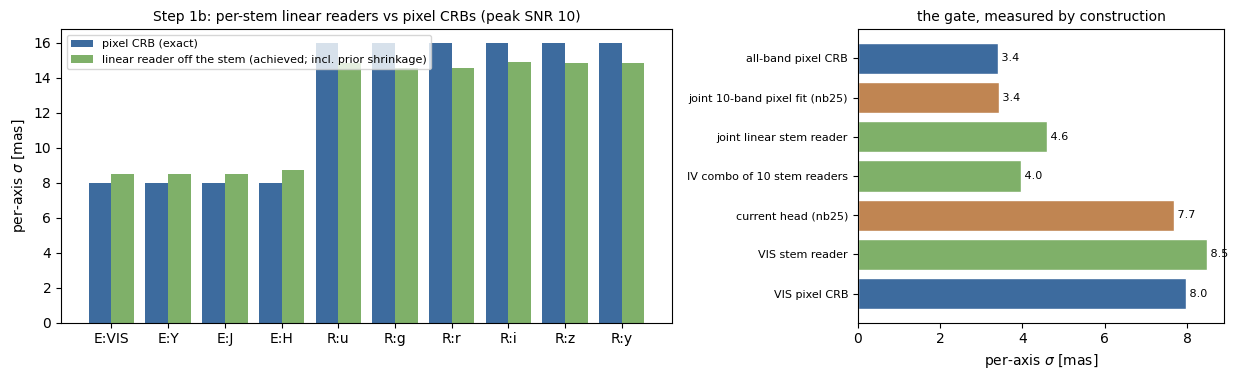

In [8]:
tr = slice(0, N_TRAIN)
va = slice(N_TRAIN, N_TRAIN+N_VAL)
te = slice(N_TRAIN+N_VAL, N_REAL)
n_te = N_REAL - N_TRAIN - N_VAL
PRIOR_STD_MAS = VIS_MAS*0.5/np.sqrt(3.0)     # uniform +-0.5 px offsets -> 28.9 mas/axis

def dual_ridge(Xa, yk):
    # dual (kernel) ridge, alpha by validation MSE; returns (val_pred, test_pred)
    mu = Xa[tr].mean(0)
    Xc_ = Xa - mu
    Ktr = Xc_[tr] @ Xc_[tr].T
    Kva, Kte = Xc_[va] @ Xc_[tr].T, Xc_[te] @ Xc_[tr].T
    scale = np.trace(Ktr)/N_TRAIN
    best = (np.inf, None, None)
    for am in [1e-4, 1e-3, 1e-2, 1e-1, 1.0]:
        A = np.linalg.solve(Ktr + am*scale*np.eye(N_TRAIN), yk[tr])
        err = float(((Kva @ A - yk[va])**2).mean())
        if err < best[0]:
            best = (err, Kva @ A, Kte @ A)
    return best[1], best[2]

def calib_slope(pv, ytruth):
    # ridge shrinks toward 0; the bias is proportional to the TRUE offset and thus
    # SHARED across bands -- it must be divided out before any combination
    return max(float((pv*ytruth).sum()/(ytruth**2).sum()), 0.05)

pred_va, pred_te_r = {}, {}
for b in BAND_INFO:
    pv = np.zeros((N_VAL, len(pts), 2)); pt = np.zeros((n_te, len(pts), 2))
    for k in range(len(pts)):
        pv[:, k], pt[:, k] = dual_ridge(X[b][:, k].astype(np.float32), Yofs[:, k])
    pred_va[b], pred_te_r[b] = pv, pt
print('per-band ridge fits done', flush=True)

sig_dec = {b: np.sqrt(((pred_te_r[b]-Yofs[te])**2).mean(axis=(0, 2)))*VIS_MAS for b in BAND_INFO}
gam = {b: np.array([calib_slope(pred_va[b][:, k], Yofs[va, k]) for k in range(len(pts))])
       for b in BAND_INFO}
mse_c = {b: np.array([((pred_va[b][:, k]/gam[b][k]-Yofs[va, k])**2).mean()
                      for k in range(len(pts))]) for b in BAND_INFO}
w_iv = np.stack([1.0/np.clip(mse_c[b], 1e-12, None) for b in BAND_INFO])
comb = np.einsum('bs,tbsa->tsa', w_iv,
                 np.stack([pred_te_r[b]/gam[b][None, :, None] for b in BAND_INFO], axis=1)) \
       / w_iv.sum(0)[None, :, None]
sig_comb = np.sqrt(((comb - Yofs[te])**2).mean(axis=(0, 2)))*VIS_MAS

# the head prototype proper: ONE joint linear reader on all ten concatenated stem windows
pred_j = np.zeros((n_te, len(pts), 2))
for k in range(len(pts)):
    Xa = np.concatenate([X[b][:, k].astype(np.float32) for b in BAND_INFO], axis=1)
    pv, pt = dual_ridge(Xa, Yofs[:, k])
    pred_j[:, k] = pt/calib_slope(pv, Yofs[va, k])
sig_joint = np.sqrt(((pred_j - Yofs[te])**2).mean(axis=(0, 2)))*VIS_MAS

crb_b = {b: np.median(1/np.sqrt(F_pix_band[b])) for b in BAND_INFO}
print('per-band linear decoder off the stem (median over sources, per-axis mas):')
print(f'  {"band":12s} {"decoder":>8s} {"info-corrected":>14s} {"pixel CRB":>10s}')
for b in BAND_INFO:
    m = np.median(sig_dec[b])
    info = 1.0/np.sqrt(max(1.0/m**2 - 1.0/PRIOR_STD_MAS**2, 1e-9))  # remove prior-shrinkage credit
    print(f'  {b:12s} {m:8.2f} {info:14.2f} {crb_b[b]:10.2f}')
print(f'IV combo of 10 calibrated readers : {np.median(sig_comb):.2f} mas')
print(f'joint linear reader (all 10 stems): {np.median(sig_joint):.2f} mas')
print(f'(all-band CRB {F_pix_all_med:.2f}, joint pixel fit 3.42, current head 7.69)')

x = np.arange(len(BAND_INFO))
labels2 = [b.replace('euclid_', 'E:').replace('rubin_', 'R:') for b in BAND_INFO]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9), gridspec_kw={'width_ratios': [2, 1.2]})
axes[0].bar(x-0.2, [crb_b[b] for b in BAND_INFO], 0.4, label='pixel CRB (exact)', color='#3d6b9e')
axes[0].bar(x+0.2, [np.median(sig_dec[b]) for b in BAND_INFO], 0.4,
            label='linear reader off the stem (achieved; incl. prior shrinkage)', color='#7fb069')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels2)
axes[0].set_ylabel(r'per-axis $\sigma$ [mas]'); axes[0].legend(fontsize=8)
axes[0].set_title(f'Step 1b: per-stem linear readers vs pixel CRBs (peak SNR {CFG["snr"]:.0f})', fontsize=10)
names = ['all-band pixel CRB', 'joint 10-band pixel fit (nb25)', 'joint linear stem reader',
         'IV combo of 10 stem readers', 'current head (nb25)', 'VIS stem reader', 'VIS pixel CRB']
vals = [F_pix_all_med, 3.42, np.median(sig_joint), np.median(sig_comb), 7.69,
        np.median(sig_dec['euclid_VIS']), crb_b['euclid_VIS']]
cols = ['#3d6b9e', '#c08552', '#7fb069', '#7fb069', '#c08552', '#7fb069', '#3d6b9e']
yp = np.arange(len(names))[::-1]
for yi, n_, v, c in zip(yp, names, vals, cols):
    axes[1].barh(yi, v, color=c, edgecolor='white')
    axes[1].text(v, yi, f' {v:.1f}', va='center', fontsize=8)
axes[1].set_yticks(yp); axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel(r'per-axis $\sigma$ [mas]')
axes[1].set_title('the gate, measured by construction', fontsize=10)
plt.tight_layout(); plt.savefig(OUT/'step1b_decoder_bound.png', dpi=150); plt.show()

json.dump(dict(per_band_decoder={b: float(np.median(sig_dec[b])) for b in BAND_INFO},
               per_band_crb={b: float(crb_b[b]) for b in BAND_INFO},
               iv_combined=float(np.median(sig_comb)), joint_reader=float(np.median(sig_joint)),
               all_band_crb=float(F_pix_all_med), prior_std_mas=float(PRIOR_STD_MAS)),
          open(OUT/'step1b_decoder_bound.json', 'w'), indent=1)
np.savez(OUT/'step1b_arrays.npz', sig_comb=sig_comb, sig_joint=sig_joint, Y_test=Yofs[te],
         **{f'sig_dec_{b}': sig_dec[b] for b in BAND_INFO})

## Verdict — both gates pass; the head project is a go

**Gate 0 (realistic-SED headroom): PASS, with a resized target.** For 1,710 real sources
the median headroom is $\sigma_{\rm VIS}/\sigma_{\rm all}=1.47$ (×2.2 in information),
growing with brightness (×1.63 at VIS SNR 10–30: 5.6 → 3.2 mas). Fisher shares for real
SEDs: VIS ≈ 46%, Rubin $g$+$r$+$i$ ≈ 32%, NISP ≈ 9%, Rubin $u$/$y$ ≈ 0 — **the head
mainly needs to read the Rubin $g/r/i$ stems well.**

**Gate 1 (stem sufficiency, decoder bound): PASS.** After removing the prior-shrinkage
credit, every stem's linear reader sits close to its band's pixel ceiling (Euclid ≈ 8.9
vs 8.0 mas; Rubin ≈ 17.0–17.4 vs 16.0, i.e. ~80–85% of the information): the stems are
near-lossless for astrometry. Combining the ten calibrated readers by inverse variance
reaches **3.96 mas**, and a single joint linear reader on all ten concatenated windows
reaches **4.59 mas** — vs the 3.40 all-band ceiling, the 3.42 joint pixel fit, and the
current head's 7.69. A *linear* readout already recovers ~74% of the ideal information
and ~3.8× the current head's; the per-band + IV structure beating the monolithic reader
at this training size independently supports the per-band-votes architecture. Calibration
lesson (applies to the trained head too): regularized readers shrink toward the offset
prior, the bias is shared across bands, and per-band slope calibration before combination
is mandatory.

**Step 2/3 design, with measured targets:** shared per-band stem reader (band embedding)
→ per-band (dx, dy, log σ) votes in the VIS frame via local WCS affines → calibrated
inverse-variance combination; bottleneck window as context; priority bands VIS + Rubin
$g/r/i$. Train on injection truth (≈0.5 mas floor; this notebook's realization generator
is the data engine) mixed with real-label batches at the 5 mas floor — this implements
the paper's own lever ("better labels convert into better measurements") plus the added
inputs. Injection-space target ≤4 mas at peak SNR 10. **Real-sky expectations are set by
rung 3 of the ladder** (nb25 §5, nb27): the bright end is conceded to classical
centroiding by design; the head's value is the statistics-dominated faint end (~×1.4).

**Caveats.** Single tile, single SNR, Gaussian PSFs, isolated sources; the ridge readers
are per-source, so they gate *information presence*, not *model generalization* — that is
what step 3 training must deliver. Next: repeat on 2–3 more tiles, at SNR 5 and 20, and
with a shared-across-sources reader.